# EDA y Feature Engineering — Wholesale Customers (Grupo 6)

Este notebook cubre las secciones **H (EDA)** e **I (Feature Engineering)** del enunciado.

**Regla de oro que seguimos aquí:** cada análisis termina con una pregunta respondida
explícitamente: *¿qué decisión de modelado, limpieza, ingeniería de variables o negocio
cambia como consecuencia de este resultado?*

**Importante sobre Feature Engineering:** este notebook **no reimplementa** las
transformaciones — las importa desde `src/features/build_features.py`, que es la
única fuente de verdad también usada en producción (`src/training/train.py`).
Esto evita tener "una lógica en el notebook y otra distinta en producción",
que el enunciado prohíbe explícitamente.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importación robusta del root del repo: busca hacia arriba el directorio
# que contiene src/, sin asumir desde dónde se lanzó Jupyter.
def _repo_root():
    p = Path.cwd()
    while p != p.parent and not (p / "src").exists():
        p = p.parent
    if not (p / "src").exists():
        raise RuntimeError("No se encontró el directorio raíz del repo (src/)")
    return p


sys.path.append(str(_repo_root()))

from src.features.build_features import COLS_GASTO, FeatureBuilder

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
RAW_DIR = Path("../data/raw")
df = pd.read_csv(RAW_DIR / "wholesale_customers_raw.csv")
print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset: 440 filas, 8 columnas


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
0,2,12669,9656,7561,214,2674,1338,3
1,2,7057,9810,9568,1762,3293,1776,3
2,2,6353,8808,7684,2405,3516,7844,3
3,1,13265,1196,4221,6404,507,1788,3
4,2,22615,5410,7198,3915,1777,5185,3


## Análisis 1 — Distribución de las variables de gasto (Skewness)

Ya identificamos en el diagnóstico de Data Quality que las variables de gasto
tienen valores extremos. Aquí lo cuantificamos con skewness y lo visualizamos.

Skewness por variable:
Delicassen          11.151586
Frozen               5.907986
Milk                 4.053755
Detergents_Paper     3.631851
Grocery              3.587429
Fresh                2.561323
dtype: float64


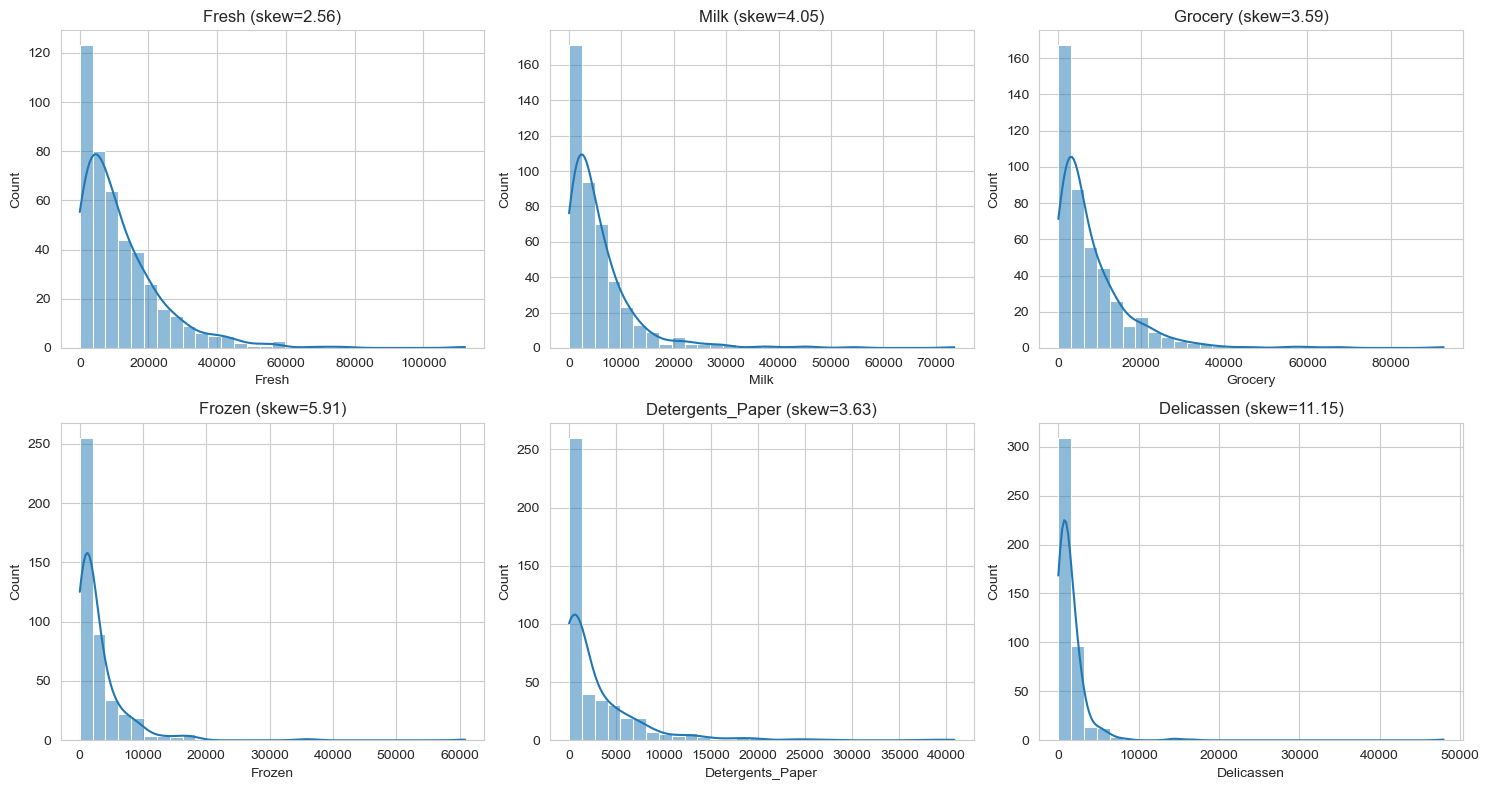

In [3]:
skew_vals = df[COLS_GASTO].skew().sort_values(ascending=False)
print("Skewness por variable:")
print(skew_vals)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), COLS_GASTO):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

**Resultado:** todas las variables de gasto tienen skewness alto (> 2 en la mayoría),
con `Delicassen` siendo la más sesgada. Esto era esperable en datos de gasto monetario
(pocos clientes grandes concentran mucho volumen).

**Decisión que cambia:** aplicamos **log-transform (log1p)** a las 6 variables de gasto
antes de escalar y clusterizar. Sin esta transformación, K-Means (basado en distancia
euclidiana) estaría dominado por los clientes de mayor volumen, ignorando diferencias
de *patrón de compra* entre clientes más pequeños. Esta transformación ya está
implementada en `FeatureBuilder._log_transform()`, no se reimplementa aquí.

## Análisis 2 — Correlación entre categorías de gasto

¿Existen categorías tan correlacionadas que aportan información redundante al
clustering?

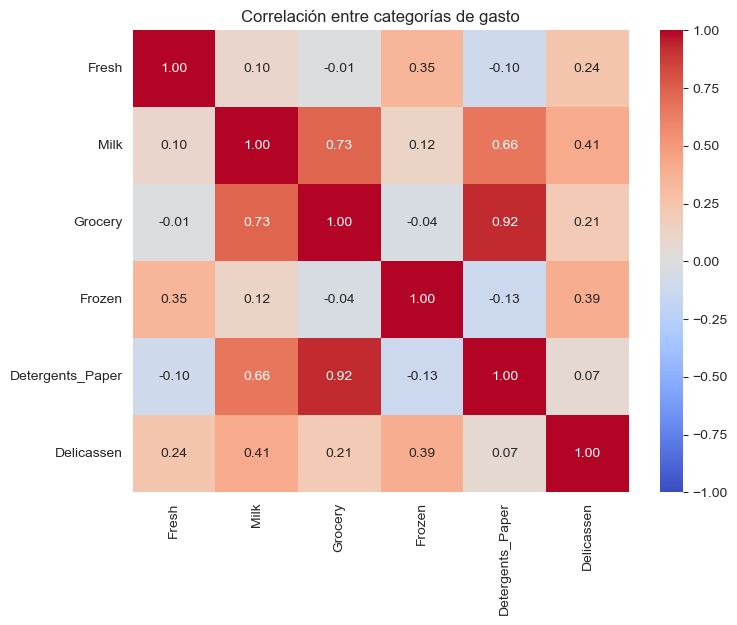

In [4]:
corr = df[COLS_GASTO].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlación entre categorías de gasto")
plt.show()

**Resultado:** `Grocery` y `Detergents_Paper` presentan una correlación alta
(> 0.9), y `Grocery`-`Milk` también está considerablemente correlacionada. Esto
sugiere que ambas capturan un comportamiento de compra similar (posiblemente
"consumo de tienda/retail").

**Decisión que cambia:** en vez de eliminar manualmente una de las columnas
correlacionadas (lo cual perdería información y sería una decisión arbitraria),
usamos **PCA** sobre el conjunto completo de features transformadas. PCA
redistribuye la información redundante en componentes ortogonales,
resolviendo el problema de correlación excesiva sin descartar variables a mano.
Esto está implementado como parámetro opcional `n_pca_components` en
`FeatureBuilder`.

## Análisis 3 — Valores extremos (outliers) por categoría

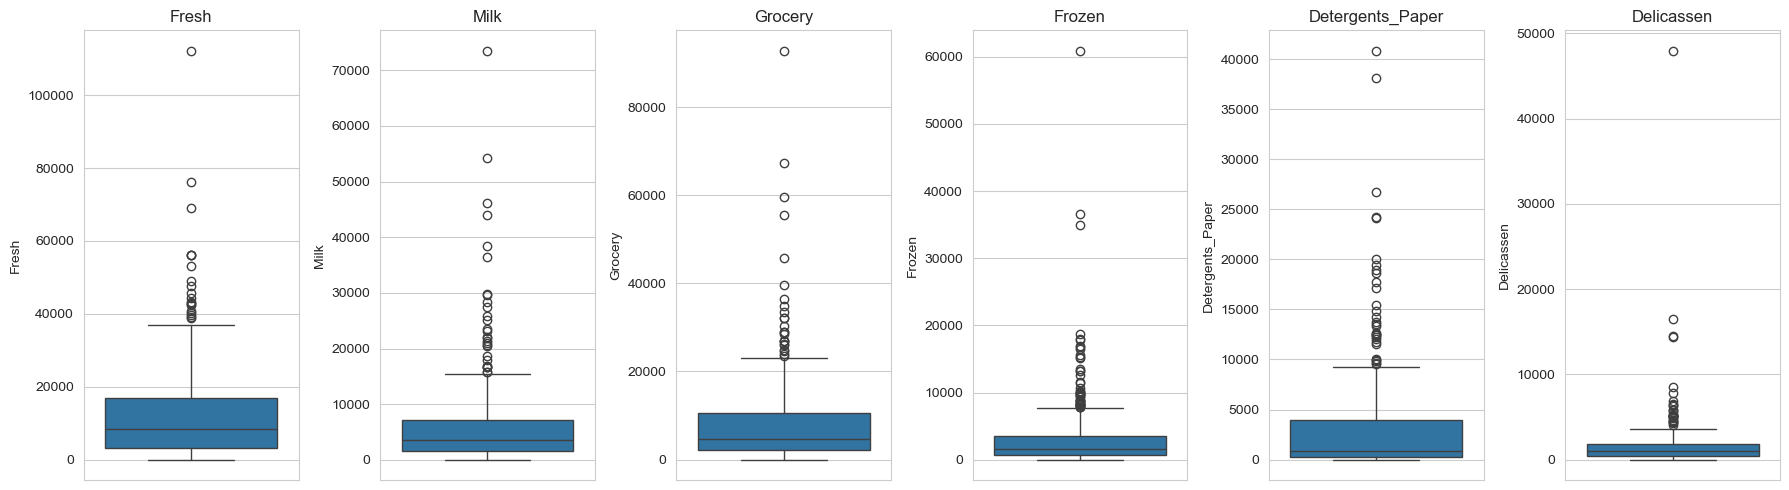

Fresh: 20 outliers (regla IQR 1.5) de 440 filas
Milk: 28 outliers (regla IQR 1.5) de 440 filas
Grocery: 24 outliers (regla IQR 1.5) de 440 filas
Frozen: 43 outliers (regla IQR 1.5) de 440 filas
Detergents_Paper: 30 outliers (regla IQR 1.5) de 440 filas
Delicassen: 27 outliers (regla IQR 1.5) de 440 filas


In [5]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, col in zip(axes, COLS_GASTO):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in COLS_GASTO:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col}: {n_outliers} outliers (regla IQR 1.5) de {len(df)} filas")

**Resultado:** hay outliers en todas las categorías, especialmente en
`Delicassen` y `Fresh`. Como ya se justificó en el diagnóstico de Data Quality
(sección F), estos representan clientes reales de alto volumen — no son errores
de captura ni datos imposibles (todos los valores son positivos y consistentes
con el resto del perfil del cliente).

**Decisión que cambia:** **no se eliminan estos registros.** Eliminar clientes
grandes sesgaría el clustering hacia perfiles "promedio", perdiendo justo el
tipo de segmento (grandes mayoristas) que el negocio necesita identificar.
La mitigación es la misma transformación logarítmica del Análisis 1, que
comprime la escala sin descartar información.

## Análisis 4 — Distribución de Channel y Region

Recordatorio del enfoque del proyecto: NO usamos `Channel` ni `Region` como
input del clustering — se usan solo al final para validar los segmentos
descubiertos. Aun así, es importante conocer su distribución de antemano.

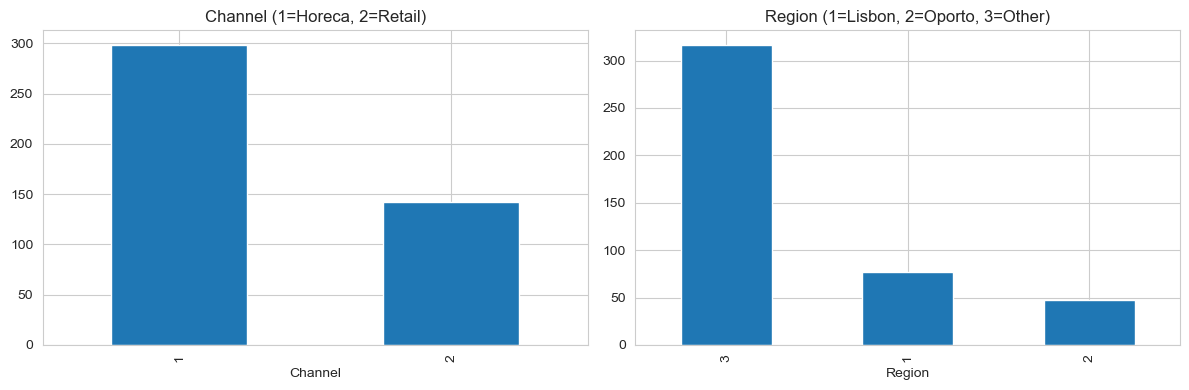

Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64
Region
3    0.718182
1    0.175000
2    0.106818
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Channel"].value_counts().plot(kind="bar", ax=axes[0], title="Channel (1=Horeca, 2=Retail)")
df["Region"].value_counts().plot(kind="bar", ax=axes[1], title="Region (1=Lisbon, 2=Oporto, 3=Other)")
plt.tight_layout()
plt.show()

print(df["Channel"].value_counts(normalize=True))
print(df["Region"].value_counts(normalize=True))

**Resultado:** `Channel` está desbalanceado (~68% Horeca vs ~32% Retail) y
`Region` está muy concentrado (~72% en "Other"). Esto confirma que serían
variables categóricas de baja cardinalidad y desbalanceadas, poco informativas
si se usaran como input directo de un clustering basado en distancia.

**Decisión que cambia (confirma el enfoque original):** mantenemos la decisión
de **no usarlas como features de entrada**. Se usarán únicamente al final,
cruzando los clusters descubiertos contra estas dos columnas, para verificar
si el patrón de gasto revela algo más rico que la segmentación ya conocida
por canal/región.

### Elección del escalador: StandardScaler vs RobustScaler

El log1p ya comprimió las colas de los outliers legítimos (Análisis 3), así
que conviene verificar empíricamente si sigue haciendo falta un escalador
robusto a extremos. Comparamos el máximo |z-score| global en tres escenarios.

**Decisión que cambia:** mantenemos **StandardScaler** en `FeatureBuilder`.
Sin transformar, un solo cliente distorsiona toda la escala (máximo |z| =
**16.48**); tras el log1p baja a **6.36**, eliminando la distorsión
patológica. El residuo (6.36 vs 4.54 bajo RobustScaler) no es ruido que
convierta atenuar: **son justamente los clientes de alto volumen que el
negocio quiere capturar como segmento propio**, y comprimirlos más borraría
parte de la señal de interés. Estandarizar además deja todas las dimensiones
comparables (media 0, desviación 1), supuesto implícito de K-Means. Si en
training los clusters resultaran dominados por volumen puro, esta decisión
se revisará con esa evidencia.

In [7]:
from sklearn.preprocessing import RobustScaler, StandardScaler

X_raw = df[COLS_GASTO]
X_log = np.log1p(X_raw)


def _max_abs_z(X):
    """Máximo |z-score| global tras estandarizar las columnas de X."""
    z = StandardScaler().fit_transform(X)
    return np.abs(z).max()


pd.Series(
    {
        "StandardScaler sin transformar": _max_abs_z(X_raw),
        "StandardScaler con log1p": _max_abs_z(X_log),
        "RobustScaler con log1p": np.abs(RobustScaler().fit_transform(X_log)).max(),
    },
    name="máximo |z| global",
).round(2)

StandardScaler sin transformar    16.48
StandardScaler con log1p           6.36
RobustScaler con log1p             4.54
Name: máximo |z| global, dtype: float64

## Análisis 5 — ¿Cuántos componentes principales se necesitan?

Las features derivadas incluyen las seis proporciones `pct_*`, que suman
exactamente 1 por construcción (**colinealidad perfecta**): una de esas seis
direcciones es matemáticamente redundante. Esto se suma a lo visto en el
Análisis 2 (correlación Grocery–Detergents_Paper ≈ 0.92): en lugar de
descartar variables a mano —decisión arbitraria y pérdida de información—,
dejamos que PCA redistribuya la información redundante en componentes
ortogonales.

Para elegir k con evidencia y no por costumbre, ajustamos PCA sobre **todo
el espectro** de componentes y aplicamos un criterio explícito: **el menor k
cuya varianza acumulada alcanza el 80%**, contrastado visualmente con el
codo del scree plot.

Criterio: menor k con >=80% de varianza acumulada -> k = 5


,PC,varianza_explicada,acumulada
0,PC1,0.4183,0.4183
1,PC2,0.1633,0.5816
2,PC3,0.1209,0.7026
3,PC4,0.0923,0.7949
4,PC5,0.0621,0.8569
5,PC6,0.0501,0.9071
6,PC7,0.0344,0.9414
7,PC8,0.0201,0.9616
8,PC9,0.0138,0.9754
9,PC10,0.0100,0.9854


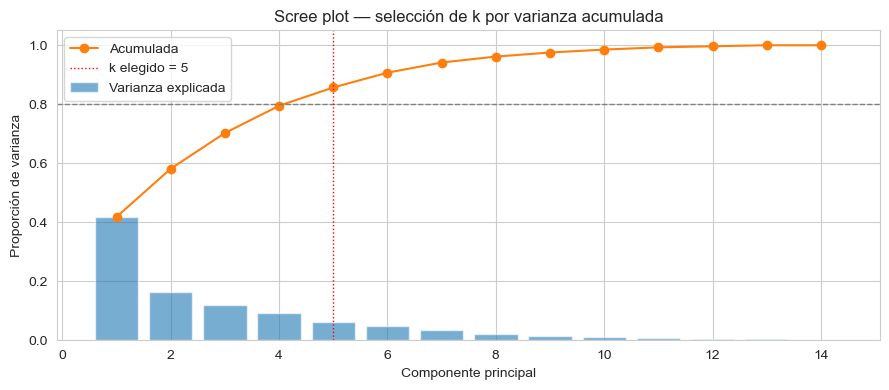

In [8]:
from sklearn.decomposition import PCA

fb_base = FeatureBuilder()  # sin PCA: construye features y escala
df_base = fb_base.fit_transform(df)
X_scaled = df_base[fb_base.cols_modelo_]

pca_full = PCA().fit(X_scaled)
var_ratio = pca_full.explained_variance_ratio_
cum_ratio = var_ratio.cumsum()

K_PCA = int(np.searchsorted(cum_ratio, 0.80) + 1)
print(f"Criterio: menor k con >=80% de varianza acumulada -> k = {K_PCA}")

display(pd.DataFrame({
    "PC": [f"PC{i + 1}" for i in range(len(var_ratio))],
    "varianza_explicada": var_ratio.round(4),
    "acumulada": cum_ratio.round(4),
}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, label="Varianza explicada")
ax.plot(range(1, len(var_ratio) + 1), cum_ratio, marker="o", color="C1", label="Acumulada")
ax.axhline(0.80, ls="--", color="gray", lw=1)
ax.axvline(K_PCA, ls=":", color="red", lw=1, label=f"k elegido = {K_PCA}")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza")
ax.set_title("Scree plot — selección de k por varianza acumulada")
ax.legend()
plt.tight_layout()
plt.show()

**Decisión que cambia:** fijamos **K_PCA = 5** como valor de
`n_pca_components` en `FeatureBuilder`: los primeros 5 componentes retienen
el **85.7%** de la varianza, mientras que con k=3 (elección inicial sin este
análisis) solo se capturaba el **70.3%**. El criterio del menor k con ≥80%
resuelve a la vez la redundancia del grupo Milk–Grocery–Detergents_Paper
(Análisis 2) y la colinealidad exacta de las proporciones (Σpct = 1):
obsérvese que PC14 aporta varianza ~0.0000 — es precisamente la dirección
redundante impuesta por esa suma constante. La fracción de varianza no
retenida (14.3%) se acepta de forma consciente y quedará registrada también
en MLflow durante el training.

## Aplicación de Feature Engineering (vía módulo reutilizable)

A partir de aquí generamos el dataset de features usando **exactamente el
mismo código** que usarán `src/training/train.py` y la CLI
`python src/features/build_features.py`. El número de componentes viene del
análisis anterior (`K_PCA`), no de una elección arbitraria.

In [9]:
fb = FeatureBuilder(n_pca_components=K_PCA)
df_features = fb.fit_transform(df)

print(f"Shape original: {df.shape}")
print(f"Shape con features: {df_features.shape}")
df_features.head()

Shape original: (440, 8)
Shape con features: (440, 14)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,gasto_total,PC1,PC2,PC3,PC4,PC5
0,2,3,12669,9656,7561,214,2674,1338,34112,-1.516108,-0.038636,1.069576,1.011205,0.987996
1,2,3,7057,9810,9568,1762,3293,1776,33266,-2.042941,1.088022,0.346898,0.014524,0.549010
2,2,3,6353,8808,7684,2405,3516,7844,36610,-1.846597,3.648528,-0.386042,1.978031,-0.880548
3,1,3,13265,1196,4221,6404,507,1788,27381,1.768045,1.329871,-0.281868,-0.699361,-0.862853
4,2,3,22615,5410,7198,3915,1777,5185,46100,0.211585,2.369157,0.960299,0.608812,-0.535440


In [10]:
# Confirmación sobre las componentes finalmente retenidas
print("Varianza explicada:", fb.pca.explained_variance_ratio_.round(4))
print("Acumulada:", fb.pca.explained_variance_ratio_.cumsum().round(4))

Varianza explicada: [0.4183 0.1633 0.1209 0.0923 0.0621]
Acumulada: [0.4183 0.5816 0.7026 0.7949 0.8569]


varianza mostrada arriba (**85.7% acumulada con k=5**, por criterio
explícito del ≥80%).

Antes de comprometer la etapa de training, verificamos rápidamente que las
features elegidas producen estructura de grupos: silhouette media para
k = 2..6 sobre las componentes finales. **Es solo un preview**: la decisión
formal de algoritmo y k se tomará con validación completa y quedará
registrada en MLflow en la etapa de training.

C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\quesa\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_

2    0.322
3    0.257
4    0.232
5    0.234
6    0.233
Name: silhouette_media, dtype: float64


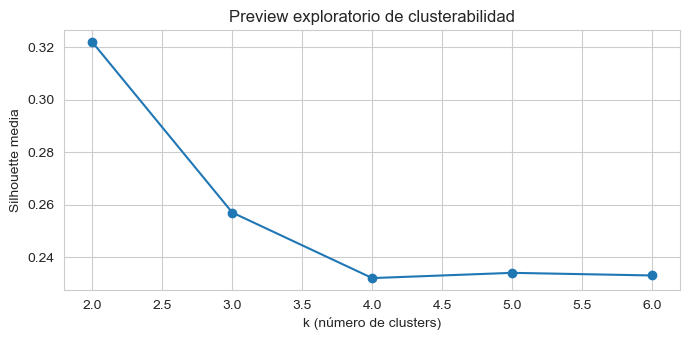

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = df_features[fb.cols_finales_]

scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster)
    scores[k] = silhouette_score(X_cluster, labels)

sil = pd.Series(scores, name="silhouette_media").round(3)
print(sil)

plt.figure(figsize=(7, 3.5))
plt.plot(list(scores.keys()), sil.values, marker="o")
plt.xlabel("k (número de clusters)")
plt.ylabel("Silhouette media")
plt.title("Preview exploratorio de clusterabilidad")
plt.tight_layout()
plt.show()

**Decisión que cambia:** sí existe estructura clusterizable: silhouette de
**0.322 para k=2** y **0.257 para k=3**, estabilizándose en ~0.23 para k≥4.
La cadena de decisiones de esta etapa (log1p → derivadas → escalado → PCA)
produce segmentos separables sin recurrir a Channel/Region, lo cual es
prometedor: si al cruzar los clusters contra esas variables (validación
externa) el k=2 dominante coincidiera con Horeca/Retail, significaría que el
modelo redescubre la segmentación ya conocida; el objetivo del proyecto es
que encuentre algo más rico que eso. La selección formal de algoritmo y k,
con comparación de alternativos y registro en MLflow, corresponde a la etapa
de training.

## Resumen de decisiones tomadas en esta etapa

| Hallazgo | Decisión | Dónde se implementa |
|---|---|---|
| Skewness alto en variables de gasto | Log-transform (log1p) | `FeatureBuilder._log_transform` |
| Correlación excesiva (Grocery–Detergents_Paper ≈ 0.92) + Σpct = 1 exacto | PCA con k elegido por varianza acumulada ≥80% | `FeatureBuilder(n_pca_components=K_PCA)` |
| Outliers son clientes reales, no errores | No se eliminan; se comprimen con log | `FeatureBuilder._log_transform` |
| Colas acotadas tras log1p (max \|z\| verificado) | StandardScaler; RobustScaler innecesario | `FeatureBuilder.scaler` |
| Perfil de composición ≠ volumen total | Proporciones + ratio perecederos/no perecederos + entropía | `_proporciones_gasto`, `_ratio_perecederos`, `_indice_diversificacion` |
| Existe estructura clusterizable (preview silhouette) | Avanzar a training formal comparando algoritmos | `src/training/train.py` (pendiente) |
| Channel/Region desbalanceadas y de baja cardinalidad | No como input; solo validación externa posterior | Notebook de evaluación de clusters (pendiente) |

**Siguiente etapa:** `python src/features/build_features.py` persiste estas
features en `data/processed/` junto con metadata que hereda `data_version`
de la ingesta (parámetro obligatorio en MLflow). `src/training/train.py`
las consumirá para entrenar y comparar modelos de clustering, registrando
cada experimento en MLflow.